In [ ]:
# === 0) Setup ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If your CSV is in the same folder as the notebook:
df = pd.read_csv("spain_retreats.csv")


df.head()

,retreat_name,location,min_price_usd,max_price_usd,duration_days,classes_codes,meals_included,accommodation_score,interested,review_score,number_of_reviews
0,8 day reconnect with inner truth retreat in Te...,Island,1374.0,1913.0,8,"1,2,3",3,3,69,4.75,26
1,3 Day Sacred San Pedro Ceremony & Integration ...,Nature,344.0,344.0,3,"1,3,4",3,2,32,5.00,9
2,"3 Day Relax, Healthy, Holidays & Yoga Retreat ...",Nature,344.0,692.0,3,"1,2,3",3,4,14,4.96,48
3,7 day “Roots to the Heart” Breathwork Retreat ...,Island,1803.0,2060.0,7,"1,2,3",3,3,34,4.96,43
4,5 day Yogi Heartful Living Retreat in El Brosq...,Nature,717.0,893.0,5,"1,2,3",3,3,27,4.85,33


In [ ]:
# === 1) Basic cleaning + type checks ===
# Make sure numeric columns are numeric (and keep NaN if any)
num_cols = [
    "min_price_usd", "max_price_usd", "duration_days", "meals_included",
    "accommodation_score", "interested", "review_score", "number_of_reviews"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Ensure min <= max (swap if needed)
swap_mask = df["min_price_usd"] > df["max_price_usd"]
df.loc[swap_mask, ["min_price_usd", "max_price_usd"]] = df.loc[swap_mask, ["max_price_usd", "min_price_usd"]].values

# Standardize location capitalization (optional)
df["location"] = df["location"].astype(str).str.strip().str.title()

df.describe(include="all")


,retreat_name,location,min_price_usd,max_price_usd,duration_days,classes_codes,meals_included,accommodation_score,interested,review_score,number_of_reviews
count,48,48,48.000000,48.000000,48.000000,48,48.000000,48.000000,48.000000,45.000000,48.000000
unique,48,3,NaN,NaN,NaN,14,NaN,NaN,NaN,NaN,NaN
top,8 day reconnect with inner truth retreat in Te...,Nature,NaN,NaN,NaN,"1,2,3",NaN,NaN,NaN,NaN,NaN
freq,1,22,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1045.354167,1467.395833,5.250000,NaN,2.229167,2.708333,13.354167,4.870667,43.208333
std,NaN,NaN,627.395341,814.432755,1.707306,NaN,1.056683,0.849489,15.218256,0.191719,79.601924
min,NaN,NaN,186.000000,232.000000,2.000000,NaN,0.000000,1.000000,0.000000,3.980000,0.000000
25%,NaN,NaN,557.000000,762.250000,4.000000,NaN,2.000000,2.000000,3.000000,4.850000,4.750000
50%,NaN,NaN,899.000000,1416.000000,5.000000,NaN,3.000000,3.000000,8.000000,4.930000,12.000000
75%,NaN,NaN,1322.250000,2036.750000,7.000000,NaN,3.000000,3.000000,15.250000,5.000000,44.250000


In [ ]:
# Average price and price per day
df["avg_price_usd"] = (df["min_price_usd"] + df["max_price_usd"]) / 2
df["price_per_day_usd"] = df["avg_price_usd"] / df["duration_days"]

# Parse class codes (stored like "1,2,3" or "0")
def parse_codes(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return []
    if s == "0":
        return []
    return [c.strip() for c in s.split(",") if c.strip() != ""]

df["class_codes_list"] = df["classes_codes"].apply(parse_codes)
df["class_count"] = df["class_codes_list"].apply(len)

# Optional: log popularity for robustness checks
df["log_interested"] = np.log1p(df["interested"])

# Optional: popularity categories (good for Tableau-style charts)
# adjust bins if you want a different split
df["popularity_cat"] = pd.cut(
    df["interested"],
    bins=[-0.1, 5, 20, df["interested"].max()],
    labels=["Low (0–5)", "Medium (6–20)", "High (21+)"]
)

df[["retreat_name","location","interested","avg_price_usd","price_per_day_usd","class_count","popularity_cat"]].head()


,retreat_name,location,interested,avg_price_usd,price_per_day_usd,class_count,popularity_cat
0,8 day reconnect with inner truth retreat in Te...,Island,69,1643.5,205.437500,3,High (21+)
1,3 Day Sacred San Pedro Ceremony & Integration ...,Nature,32,344.0,114.666667,3,High (21+)
2,"3 Day Relax, Healthy, Holidays & Yoga Retreat ...",Nature,14,518.0,172.666667,3,Medium (6–20)
3,7 day “Roots to the Heart” Breathwork Retreat ...,Island,34,1931.5,275.928571,3,High (21+)
4,5 day Yogi Heartful Living Retreat in El Brosq...,Nature,27,805.0,161.000000,3,High (21+)


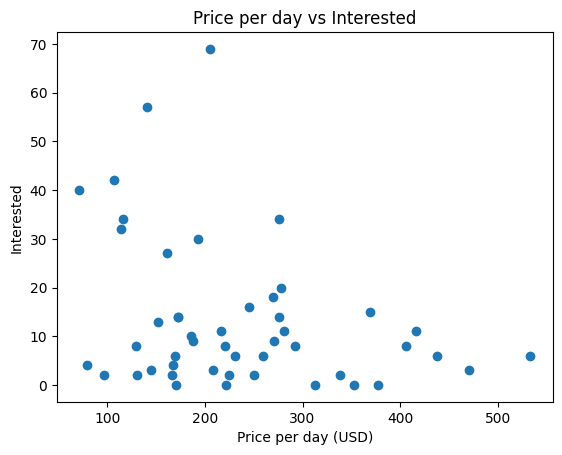

In [ ]:
# === 3) Analysis 1: Price per day vs Popularity (Interested) ===
plt.figure()
plt.scatter(df["price_per_day_usd"], df["interested"])
plt.xlabel("Price per day (USD)")
plt.ylabel("Interested")
plt.title("Price per day vs Interested")
plt.show()


In [ ]:
# Quick correlation (Pearson)
corr_price = df[["price_per_day_usd", "interested"]].corr().iloc[0,1]
print("Correlation (price_per_day_usd vs interested):", round(corr_price, 3))

Correlation (price_per_day_usd vs interested): -0.305


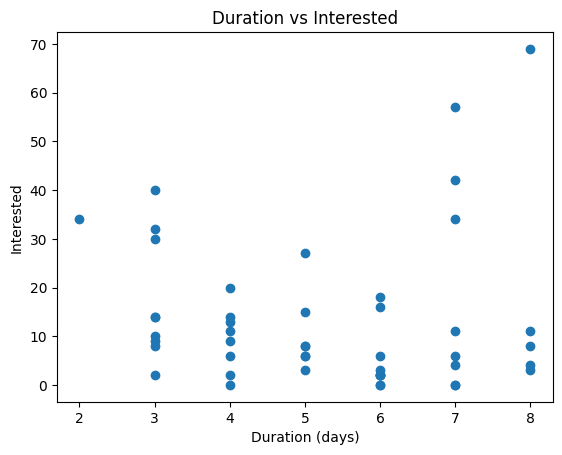

In [ ]:
# === 4) Analysis 2: Duration vs Popularity ===
plt.figure()
plt.scatter(df["duration_days"], df["interested"])
plt.xlabel("Duration (days)")
plt.ylabel("Interested")
plt.title("Duration vs Interested")
plt.show()

In [ ]:
corr_dur = df[["duration_days", "interested"]].corr().iloc[0,1]
print("Correlation (duration_days vs interested):", round(corr_dur, 3))

Correlation (duration_days vs interested): -0.009


          count       mean  median
location                          
Nature       22  13.636364     8.5
Island       16  13.500000     8.0
City         10  12.500000    10.5


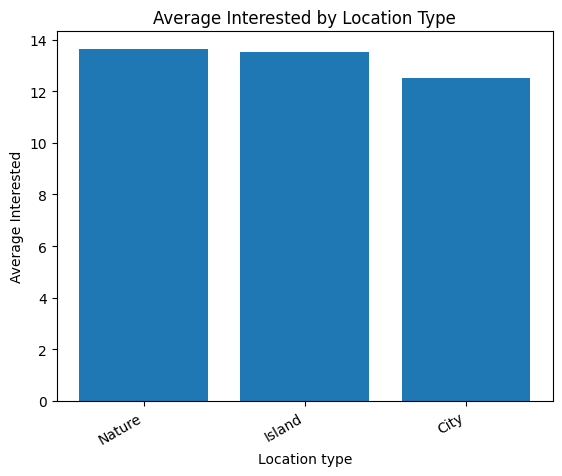

In [ ]:
# === 5) Analysis 3: Location type vs Popularity ===
location_summary = (
    df.groupby("location")["interested"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)
print(location_summary)

plt.figure()
plt.bar(location_summary.index, location_summary["mean"])
plt.xlabel("Location type")
plt.ylabel("Average Interested")
plt.title("Average Interested by Location Type")
plt.xticks(rotation=30, ha="right")
plt.show()

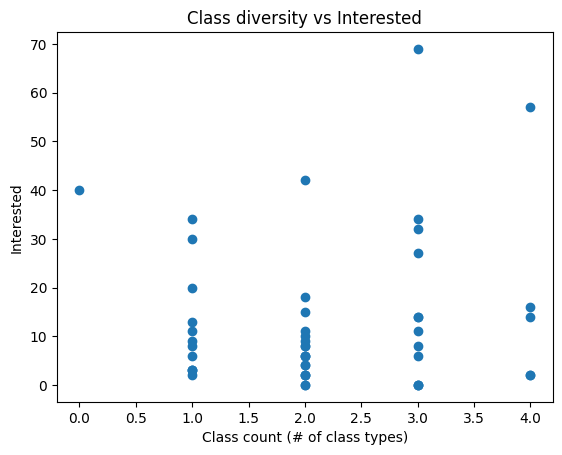

             count       mean  median
class_count                          
0                1  40.000000    40.0
1               12  11.833333     8.5
2               18   8.500000     6.0
3               12  17.916667    12.5
4                5  18.200000    14.0


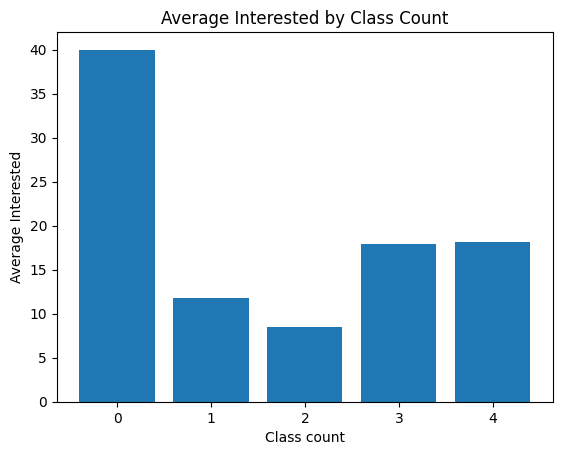

In [ ]:
# === 6) Analysis 4: Class diversity (class_count) vs Popularity ===
plt.figure()
plt.scatter(df["class_count"], df["interested"])
plt.xlabel("Class count (# of class types)")
plt.ylabel("Interested")
plt.title("Class diversity vs Interested")
plt.show()

classcount_summary = (
    df.groupby("class_count")["interested"]
      .agg(["count", "mean", "median"])
      .sort_index()
)
print(classcount_summary)

plt.figure()
plt.bar(classcount_summary.index.astype(str), classcount_summary["mean"])
plt.xlabel("Class count")
plt.ylabel("Average Interested")
plt.title("Average Interested by Class Count")
plt.show()

                count       mean  median
meals_included                          
0                   6   6.000000     4.0
1                   4  17.250000    10.5
2                  11   9.454545     6.0
3                  27  16.000000    10.0


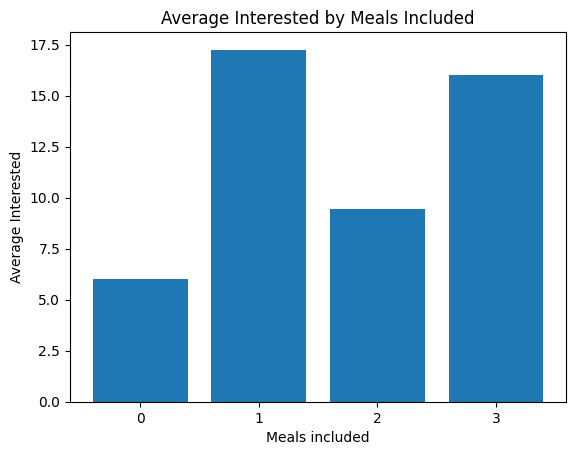

In [ ]:
# === 7) Analysis 5: Meals included vs Popularity ===
meals_summary = (
    df.groupby("meals_included")["interested"]
      .agg(["count", "mean", "median"])
      .sort_index()
)
print(meals_summary)

plt.figure()
plt.bar(meals_summary.index.astype(str), meals_summary["mean"])
plt.xlabel("Meals included")
plt.ylabel("Average Interested")
plt.title("Average Interested by Meals Included")
plt.show()

In [ ]:

# A simple correlation table for your numeric features
features = [
    "interested",
    "price_per_day_usd",
    "duration_days",
    "meals_included",
    "accommodation_score",
    "class_count",
    "review_score",
    "number_of_reviews",
]
corr = df[features].corr(numeric_only=True).sort_values("interested", ascending=False)
corr[["interested"]]

,interested
interested,1.000000
meals_included,0.190664
review_score,0.102976
class_count,0.095643
accommodation_score,0.036139
duration_days,-0.009213
number_of_reviews,-0.109923
price_per_day_usd,-0.304657


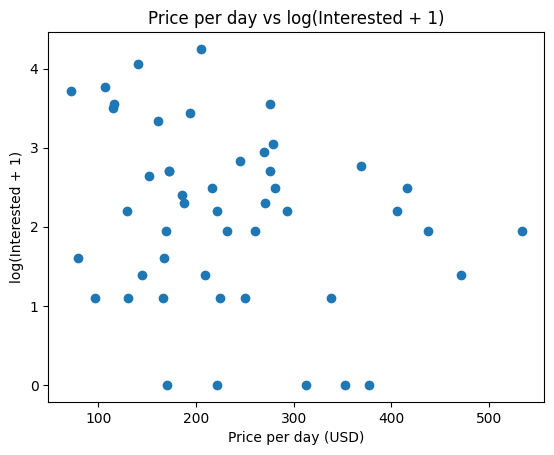

In [ ]:
#Compare raw interested vs log_interested
plt.figure()
plt.scatter(df["price_per_day_usd"], df["log_interested"])
plt.xlabel("Price per day (USD)")
plt.ylabel("log(Interested + 1)")
plt.title("Price per day vs log(Interested + 1)")
plt.show()

In [ ]:
df["min_price_usd"].describe()

,min_price_usd
count,48.000000
mean,1045.354167
std,627.395341
min,186.000000
25%,557.000000
50%,899.000000
75%,1322.250000
max,2696.000000


In [ ]:
#what is the average minimum price per day

df["min_price_per_day"] = df["min_price_usd"] / df["duration_days"]
df["min_price_per_day"].mean()

np.float64(196.52063492063493)

How does daily price Sadhanalaya compare to market price?


In [ ]:
 # approximate daily price sadhanalaya in USD
sadhanalaya_price = 45 * 1.1
#create daily dorm price for each retreat
df["min_price_per_day"] = df["min_price_usd"] / df["duration_days"]

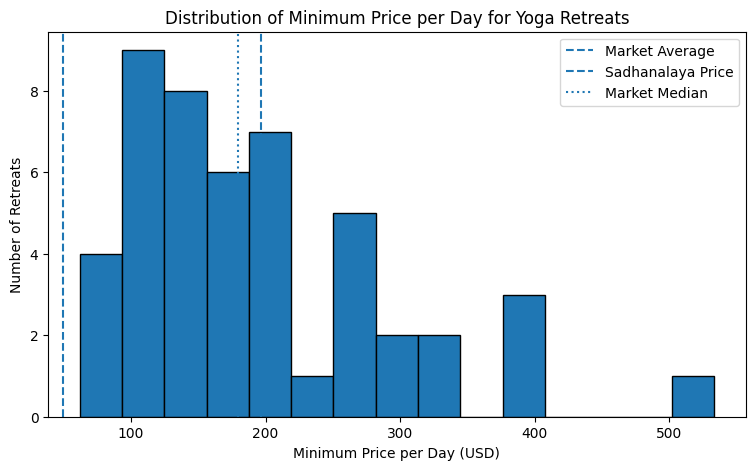

In [ ]:
#Make a price distribution plot for daily price sadhanalaya compared to minimum daily prices (shared dorm room prices) of other retreats
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.hist(df["min_price_per_day"], bins=15, edgecolor="black")

plt.axvline(df["min_price_per_day"].mean(),
            linestyle="--",
            label="Market Average")

plt.axvline(sadhanalaya_price,
            linestyle="--",
            label="Sadhanalaya Price")

plt.axvline(df["min_price_per_day"].median(),
            linestyle=":",
            label="Market Median")

plt.title("Distribution of Minimum Price per Day for Yoga Retreats")

plt.xlabel("Minimum Price per Day (USD)")
plt.ylabel("Number of Retreats")

plt.legend()

plt.show()

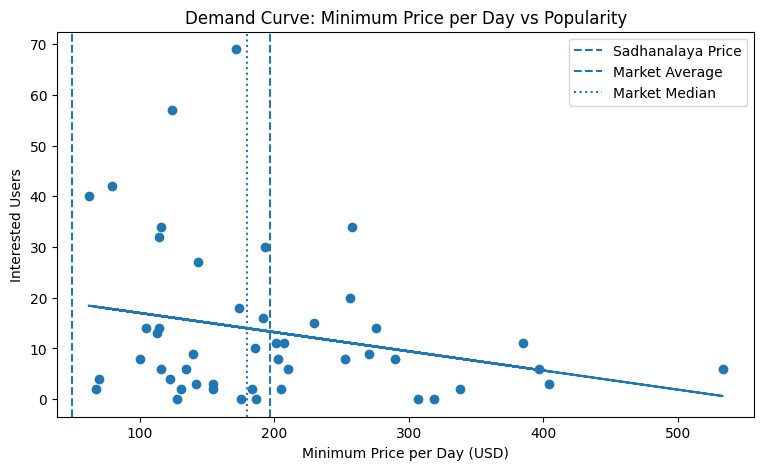

In [ ]:

plt.figure(figsize=(9,5))

plt.scatter(df["min_price_per_day"], df["interested"])

# regression line
z = np.polyfit(df["min_price_per_day"], df["interested"], 1)
p = np.poly1d(z)

plt.plot(df["min_price_per_day"], p(df["min_price_per_day"]))

plt.title("Demand Curve: Minimum Price per Day vs Popularity")
plt.xlabel("Minimum Price per Day (USD)")
plt.ylabel("Interested Users")

plt.axvline(sadhanalaya_price, linestyle="--", label="Sadhanalaya Price")

plt.axvline(df["min_price_per_day"].mean(),
            linestyle="--",
            label="Market Average")

plt.axvline(df["min_price_per_day"].median(),
            linestyle=":",
            label="Market Median")

plt.legend()

plt.show()

In [ ]:
market_mean = df["min_price_per_day"].mean()
market_median = df["min_price_per_day"].median()

#Statistical test of accomodation type

In [ ]:
df.groupby("accommodation_score")["interested"].agg(["count","mean","median"])

,count,mean,median
accommodation_score,,,
1,4,17.000000,16.0
2,14,11.571429,9.5
3,22,12.636364,8.0
4,8,16.625000,7.5


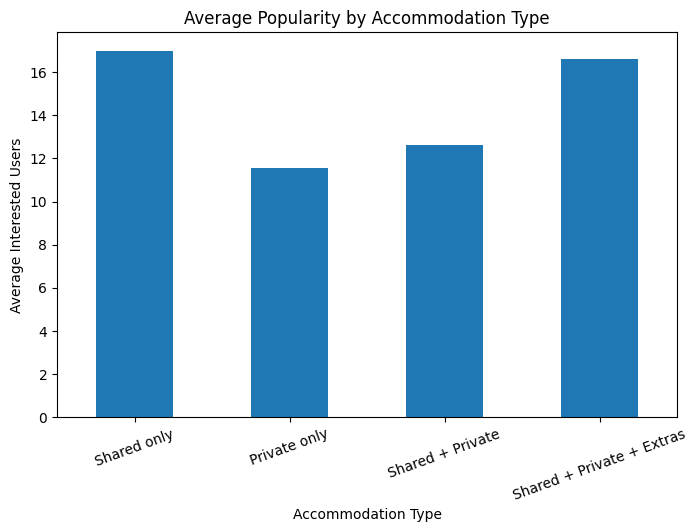

In [ ]:
import matplotlib.pyplot as plt

avg_interest = df.groupby("accommodation_score")["interested"].mean()

plt.figure(figsize=(8,5))
avg_interest.plot(kind="bar")

plt.title("Average Popularity by Accommodation Type")
plt.xlabel("Accommodation Type")
plt.ylabel("Average Interested Users")

plt.xticks(
    [0,1,2,3],
    [
        "Shared only",
        "Private only",
        "Shared + Private",
        "Shared + Private + Extras"
    ],
    rotation=20
)

plt.show()

In [ ]:
from scipy.stats import f_oneway

groups = [group["interested"].values for name, group in df.groupby("accommodation_score")]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.2669600953790107
p-value: 0.8488450757428372


In [ ]:
df["duration_days"].value_counts().sort_index()

,count
duration_days,
2,1
3,9
4,8
5,7
6,10
7,8
8,5


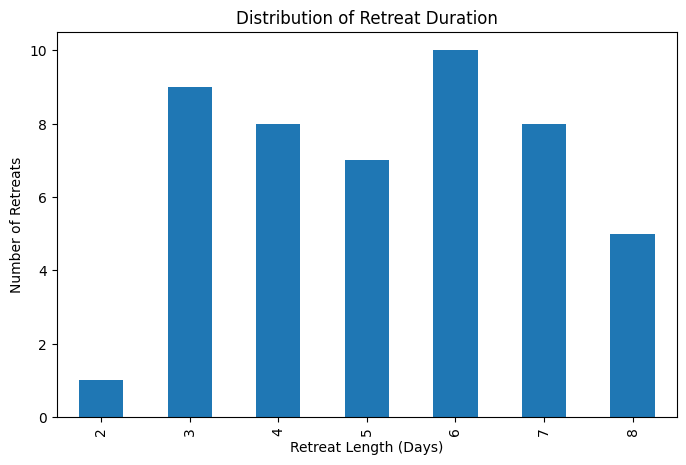

In [ ]:
duration_counts = df["duration_days"].value_counts().sort_index()

plt.figure(figsize=(8,5))
duration_counts.plot(kind="bar")

plt.title("Distribution of Retreat Duration")
plt.xlabel("Retreat Length (Days)")
plt.ylabel("Number of Retreats")

plt.show()

In [ ]:
df.groupby("duration_days")["interested"].agg(["count","mean","median"])

,count,mean,median
duration_days,,,
2,1,34.000000,34.0
3,9,17.666667,14.0
4,8,9.375000,10.0
5,7,10.428571,8.0
6,10,5.100000,2.0
7,8,19.250000,8.5
8,5,19.000000,8.0


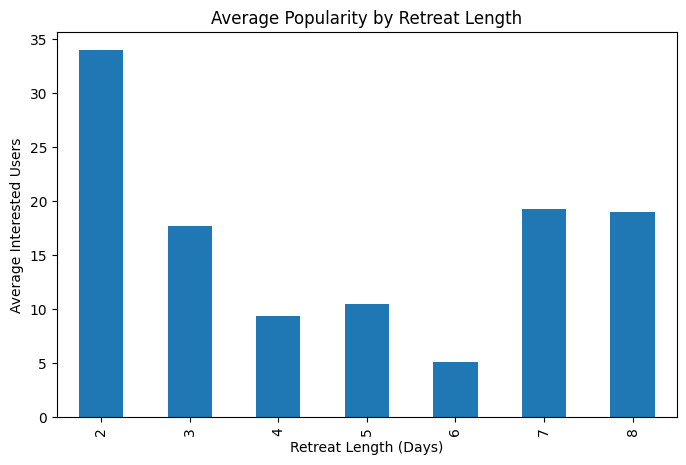

In [ ]:
avg_interest_duration = df.groupby("duration_days")["interested"].mean()

plt.figure(figsize=(8,5))
avg_interest_duration.plot(kind="bar")

plt.title("Average Popularity by Retreat Length")
plt.xlabel("Retreat Length (Days)")
plt.ylabel("Average Interested Users")

plt.show()

In [ ]:
df["retreat_length_group"] = df["duration_days"].apply(
    lambda x: "Short (2-4 days)" if x <= 4 else "Long (5+ days)"
)

In [ ]:
df.groupby("retreat_length_group")["interested"].agg(["count","mean","median"])

,count,mean,median
retreat_length_group,,,
Long (5+ days),30,12.433333,6.0
Short (2-4 days),18,14.888889,12.0


In [ ]:
from scipy.stats import ttest_ind

short_retreats = df[df["retreat_length_group"] == "Short (2-4 days)"]["interested"]
long_retreats = df[df["retreat_length_group"] == "Long (5+ days)"]["interested"]

t_stat, p_value = ttest_ind(short_retreats, long_retreats)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.5370919297702019
P-value: 0.5937927135334113


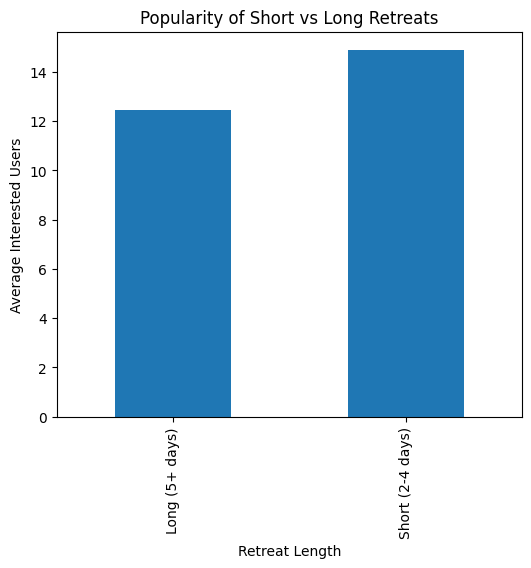

In [ ]:
avg_interest = df.groupby("retreat_length_group")["interested"].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
avg_interest.plot(kind="bar")

plt.title("Popularity of Short vs Long Retreats")
plt.xlabel("Retreat Length")
plt.ylabel("Average Interested Users")

plt.show()

<Figure size 700x500 with 0 Axes>

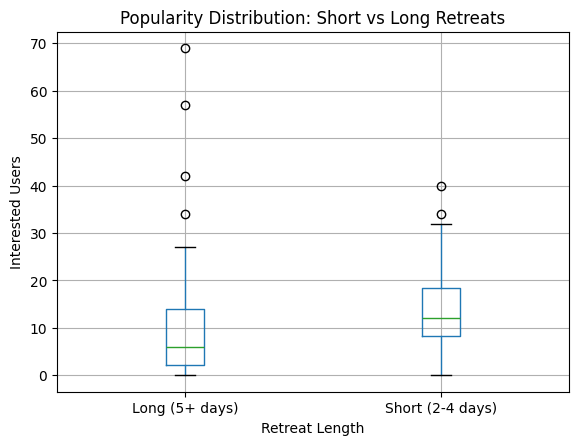

In [ ]:
plt.figure(figsize=(7,5))

df.boxplot(column="interested", by="retreat_length_group")

plt.title("Popularity Distribution: Short vs Long Retreats")
plt.suptitle("")
plt.xlabel("Retreat Length")
plt.ylabel("Interested Users")

plt.show()

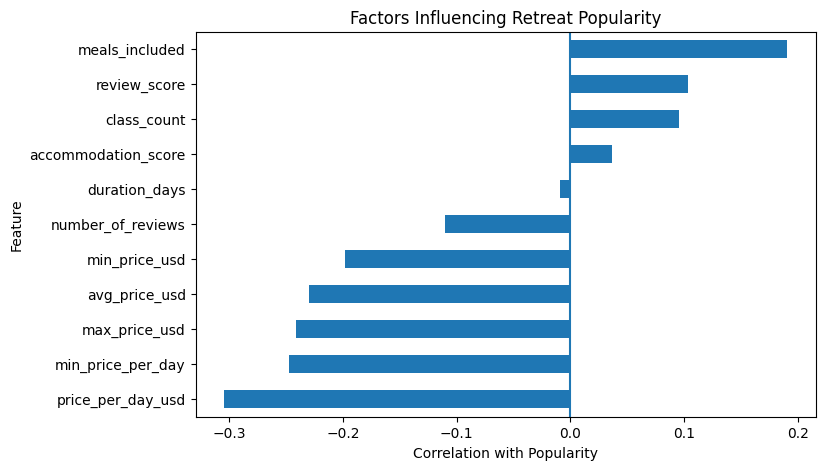

In [ ]:
# Select correlations with popularity
corr = df.corr(numeric_only=True)["interested"]


# Remove variables we don't want
corr = corr.drop(["interested", "log_interested"], errors="ignore")

# Sort them
corr = corr.sort_values()

plt.figure(figsize=(8,5))
corr.plot(kind="barh")

plt.title("Factors Influencing Retreat Popularity")
plt.xlabel("Correlation with Popularity")
plt.ylabel("Feature")

plt.axvline(0)

plt.show()

In [ ]:
df["retreat_length_bucket"] = df["duration_days"].apply(
    lambda x: "Short (2-4)" if x <= 4
    else "Medium (5-6)" if x <= 6
    else "Long (7+)"
)

In [ ]:
avg_interest_bucket = df.groupby("retreat_length_bucket")["interested"].mean()

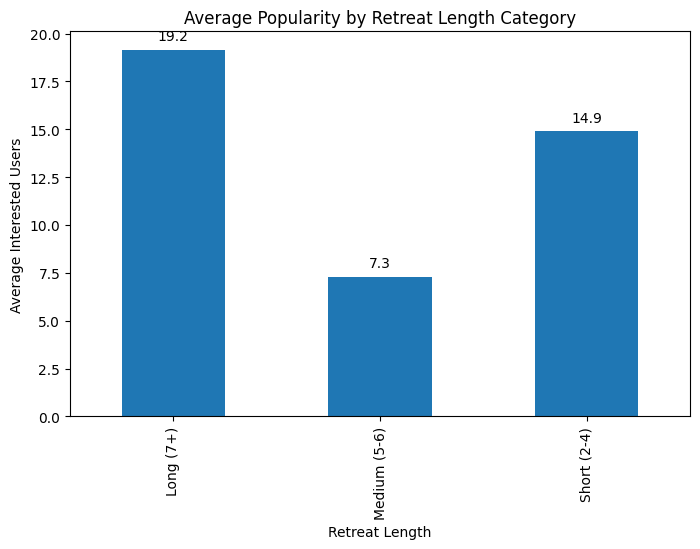

In [ ]:
plt.figure(figsize=(8,5))

bars = avg_interest_bucket.plot(kind="bar")

plt.title("Average Popularity by Retreat Length Category")
plt.xlabel("Retreat Length")
plt.ylabel("Average Interested Users")

# Add labels above bars
for i, v in enumerate(avg_interest_bucket):
    plt.text(i, v + 0.5, round(v,1), ha='center')

plt.show()

<Figure size 800x500 with 0 Axes>

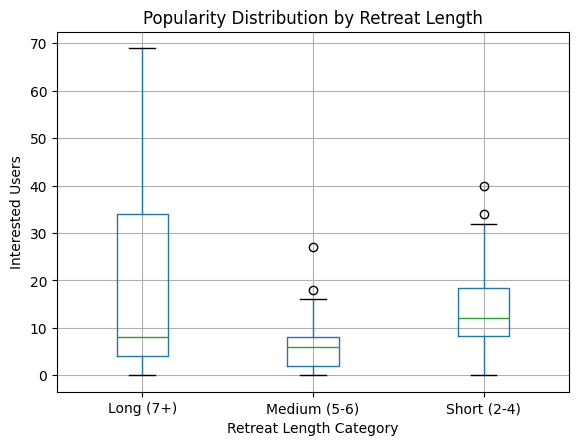

In [ ]:
plt.figure(figsize=(8,5))

df.boxplot(column="interested", by="retreat_length_bucket")

plt.title("Popularity Distribution by Retreat Length")
plt.suptitle("")  # removes automatic subtitle
plt.xlabel("Retreat Length Category")
plt.ylabel("Interested Users")

plt.show()